# Classification: ML vs Statistical Models Comparison

This notebook compares Machine Learning and Statistical models for classification problems.

## Problem Type: Classification
## Datasets:
- Iris
- Wine Classification
- Breast Cancer
- Credit Default

## Models:
**ML Models:**
- Random Forest
- Support Vector Machine
- Multi-layer Perceptron

**Statistical Models:**
- Logistic Regression (statsmodels)
- Generalized Linear Model (statsmodels)


In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import psutil
import os

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Statistical Models
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Utility Functions

Functions for dataset loading, model evaluation, and comparison.


In [ ]:
def load_dataset(dataset_name):
    """Load classification datasets."""
    from sklearn.datasets import load_iris, load_wine, load_breast_cancer
    
    if dataset_name == 'iris':
        data = load_iris()
        X, y = data.data, data.target
        feature_names = data.feature_names
        
    elif dataset_name == 'wine_classification':
        data = load_wine()
        X, y = data.data, data.target
        feature_names = data.feature_names
        
    elif dataset_name == 'breast_cancer':
        data = load_breast_cancer()
        X, y = data.data, data.target
        feature_names = data.feature_names
        
    elif dataset_name == 'credit_default':
        # Generate synthetic credit default data
        np.random.seed(42)
        n_samples = 1000
        n_features = 10
        X = np.random.randn(n_samples, n_features)
        # Create binary target with some relationship
        prob = 1 / (1 + np.exp(-(X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1)))
        y = (prob > 0.5).astype(int)
        feature_names = [f'feature_{i+1}' for i in range(n_features)]
        
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")
    
    return X, y, feature_names


def preprocess_data(X, y, feature_names):
    """Comprehensive data preprocessing pipeline."""
    from sklearn.preprocessing import RobustScaler
    from scipy import stats
    
    # Convert to DataFrame for easier handling
    df = pd.DataFrame(X, columns=feature_names)
    df['target'] = y
    
    print("📊 Data Preprocessing:")
    print("-" * 60)
    
    # 1. Data Exploration
    print(f"\n1. Data Shape: {df.shape}")
    print(f"   Features: {len(feature_names)}")
    print(f"   Samples: {len(df)}")
    print(f"   Classes: {len(np.unique(y))}")
    
    # 2. Check for missing values
    missing_values = df.isnull().sum()
    if missing_values.sum() > 0:
        print(f"\n2. Missing Values Found:")
        print(missing_values[missing_values > 0])
        # Handle missing values (mean imputation for numeric)
        df = df.fillna(df.mean())
    else:
        print("\n2. Missing Values: None ✓")
    
    # 3. Check for infinite values
    inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
    if inf_values.sum() > 0:
        print(f"\n3. Infinite Values Found:")
        print(inf_values[inf_values > 0])
        # Replace inf with NaN then fill
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(df.mean())
    else:
        print("\n3. Infinite Values: None ✓")
    
    # 4. Outlier detection using IQR method
    print("\n4. Outlier Detection (IQR method):")
    outliers_count = 0
    for col in feature_names:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            # Cap outliers (winsorization)
            df[col] = np.clip(df[col], lower_bound, upper_bound)
    if outliers_count > 0:
        print(f"   Found and capped {outliers_count} outliers")
    else:
        print("   No outliers detected ✓")
    
    # 5. Feature statistics
    print("\n5. Feature Statistics:")
    print(f"   Mean ranges: [{df[feature_names].mean().min():.2f}, {df[feature_names].mean().max():.2f}]")
    print(f"   Std ranges: [{df[feature_names].std().min():.2f}, {df[feature_names].std().max():.2f}]")
    
    # 6. Check for class imbalance
    print("\n6. Class Distribution:")
    class_counts = pd.Series(y).value_counts().sort_index()
    for cls, count in class_counts.items():
        pct = 100 * count / len(y)
        print(f"   Class {cls}: {count} ({pct:.1f}%)")
    
    # Extract preprocessed features
    X_processed = df[feature_names].values
    y_processed = df['target'].values
    
    print("\n✅ Preprocessing completed!")
    print("-" * 60)
    
    return X_processed, y_processed, feature_names


def get_memory_usage():
    """Get current memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, model_type):
    """Evaluate a model and return comprehensive metrics."""
    start_time = time.time()
    memory_before = get_memory_usage()
    
    # Train model
    if model_type == 'statistical':
        # For statsmodels, add constant
        X_train_sm = sm.add_constant(X_train)
        X_test_sm = sm.add_constant(X_test)
        
        model_result = model.fit()
        
        # Predictions (probabilities for classification)
        y_train_pred_proba = model_result.predict(X_train_sm)
        y_test_pred_proba = model_result.predict(X_test_sm)
        
        # Convert probabilities to class predictions
        y_train_pred = (y_train_pred_proba > 0.5).astype(int)
        y_test_pred = (y_test_pred_proba > 0.5).astype(int)
        
        training_time = time.time() - start_time
        
        pred_start = time.time()
        y_test_pred = (model_result.predict(X_test_sm) > 0.5).astype(int)
        prediction_time = time.time() - pred_start
        
    else:  # ML model
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        pred_start = time.time()
        y_test_pred = model.predict(X_test)
        prediction_time = time.time() - pred_start
        
        y_train_pred = model.predict(X_train)
    
    memory_after = get_memory_usage()
    memory_usage = memory_after - memory_before
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_test_pred)
    
    # Explainability score (0-100)
    if model_type == 'statistical':
        explainability = 90  # Logistic Regression and GLM
    else:
        if 'Random Forest' in model_name:
            explainability = 50
        else:
            explainability = 30
    
    results = {
        'model_name': model_name,
        'model_category': 'ml' if model_type == 'ml' else 'statistical',
        'test_accuracy': accuracy,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'memory_usage': memory_usage,
        'explainability_score': explainability,
        'y_test_pred': y_test_pred,
        'y_test': y_test
    }
    
    if model_type == 'statistical':
        results['model_result'] = model_result
    
    return results


print("✅ Utility functions defined!")


✅ Utility functions defined!


## Main Comparison Function


In [ ]:
def run_classification_comparison(dataset_name, test_size=0.2, random_state=42):
    """Run comprehensive comparison for a classification dataset."""
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name.upper()}")
    print(f"{'='*60}\n")
    
    # Load dataset
    X, y, feature_names = load_dataset(dataset_name)
    
    # Preprocess data
    X, y, feature_names = preprocess_data(X, y, feature_names)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Scale features (important for SVM and MLP)
    # Use RobustScaler for better outlier resistance
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\n📈 Training/Test Split: {len(X_train)}/{len(X_test)} samples")
    
    all_results = []
    
    # ML Models
    ml_models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state),
        'Support Vector Machine': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True),
        'Multi-layer Perceptron': MLPClassifier(hidden_layer_sizes=(100, 50), 
                                                 max_iter=500, random_state=random_state)
    }
    
    print("\n📊 Training ML Models...")
    for name, model in ml_models.items():
        print(f"  - {name}...")
        if name in ['Support Vector Machine', 'Multi-layer Perceptron']:
            results = evaluate_model(model, X_train_scaled, X_test_scaled, 
                                    y_train, y_test, name, 'ml')
        else:
            results = evaluate_model(model, X_train, X_test, 
                                    y_train, y_test, name, 'ml')
        all_results.append(results)
    
    # Statistical Models
    print("\n📈 Training Statistical Models...")
    # Logistic Regression
    print("  - Logistic Regression...")
    X_train_sm = sm.add_constant(X_train)
    logit_model = Logit(y_train, X_train_sm)
    results = evaluate_model(logit_model, X_train, X_test, y_train, y_test, 
                            'Logistic Regression (statsmodels)', 'statistical')
    all_results.append(results)
    
    # GLM
    print("  - Generalized Linear Model...")
    glm_model = GLM(y_train, X_train_sm, family=families.Binomial())
    results = evaluate_model(glm_model, X_train, X_test, y_train, y_test,
                            'Generalized Linear Model (statsmodels)', 'statistical')
    all_results.append(results)
    
    # Create results DataFrame
    results_df = pd.DataFrame([
        {
            'model_name': r['model_name'],
            'model_category': r['model_category'],
            'test_accuracy': r['test_accuracy'],
            'training_time': r['training_time'],
            'prediction_time': r['prediction_time'],
            'memory_usage': r['memory_usage'],
            'explainability_score': r['explainability_score']
        }
        for r in all_results
    ])
    
    return results_df, all_results, X_test, y_test


print("✅ Comparison function defined!")


✅ Comparison function defined!


## Run Comparisons

Run the comparison for all classification datasets.


In [4]:
# Define datasets
classification_datasets = ['iris', 'wine_classification', 'breast_cancer', 'credit_default']

# Store all results
all_dataset_results = {}

for dataset in classification_datasets:
    try:
        results_df, detailed_results, X_test, y_test = run_classification_comparison(dataset)
        all_dataset_results[dataset] = {
            'results_df': results_df,
            'detailed_results': detailed_results,
            'X_test': X_test,
            'y_test': y_test
        }
        print(f"\n✅ Completed: {dataset}")
        print(results_df[['model_name', 'model_category', 'test_accuracy', 'training_time']])
        print("\n" + "-"*60 + "\n")
    except Exception as e:
        print(f"❌ Error with {dataset}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("✅ All comparisons completed!")



Dataset: IRIS

Dataset shape: (150, 4)
Features: 4
Samples: 150
Classes: 3

📊 Training ML Models...
  - Random Forest...
  - Support Vector Machine...
  - Multi-layer Perceptron...

📈 Training Statistical Models...
  - Logistic Regression...
❌ Error with iris: endog must be in the unit interval.

Dataset: WINE_CLASSIFICATION

Dataset shape: (178, 13)
Features: 13
Samples: 178
Classes: 3

📊 Training ML Models...
  - Random Forest...
  - Support Vector Machine...
  - Multi-layer Perceptron...

📈 Training Statistical Models...
  - Logistic Regression...
❌ Error with wine_classification: endog must be in the unit interval.

Dataset: BREAST_CANCER

Dataset shape: (569, 30)
Features: 30
Samples: 569
Classes: 2

📊 Training ML Models...
  - Random Forest...


Traceback (most recent call last):
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/3794165982.py", line 9, in <module>
    results_df, detailed_results, X_test, y_test = run_classification_comparison(dataset)
                                                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/52252293.py", line 51, in run_classification_comparison
    logit_model = Logit(y_train, X_train_sm)
  File "/Users/moujar/Dev/MasterParisSaclay/T1/Applied Statistics/project/Statistical-ML-DL-Showdown/.applied-static/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py", line 479, in __init__
    raise ValueError("endog must be in the unit interval.")
ValueError: endog must be in the unit interval.
Traceback (most recent call last):
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/3794165982.py", line 9, in <module>
    results_df, detailed_results, X_test,

  - Support Vector Machine...
  - Multi-layer Perceptron...

📈 Training Statistical Models...
  - Logistic Regression...
         Current function value: inf
         Iterations: 35
❌ Error with breast_cancer: Singular matrix

Dataset: CREDIT_DEFAULT

Dataset shape: (1000, 10)
Features: 10
Samples: 1000
Classes: 2

📊 Training ML Models...
  - Random Forest...


Traceback (most recent call last):
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/3794165982.py", line 9, in <module>
    results_df, detailed_results, X_test, y_test = run_classification_comparison(dataset)
                                                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/52252293.py", line 52, in run_classification_comparison
    results = evaluate_model(logit_model, X_train, X_test, y_train, y_test,
                            'Logistic Regression (statsmodels)', 'statistical')
  File "/var/folders/dp/ptmdptw102qfsw6n40jzf7zw0000gn/T/ipykernel_55770/3134186007.py", line 54, in evaluate_model
    model_result = model.fit()
  File "/Users/moujar/Dev/MasterParisSaclay/T1/Applied Statistics/project/Statistical-ML-DL-Showdown/.applied-static/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py", line 2601, in fit
    bnryfit = super().fit(start_params=

  - Support Vector Machine...
  - Multi-layer Perceptron...

📈 Training Statistical Models...
  - Logistic Regression...
Optimization terminated successfully.
         Current function value: 0.111178
         Iterations 11
  - Generalized Linear Model...

✅ Completed: credit_default
                               model_name model_category  test_accuracy  \
0                           Random Forest             ml           0.93   
1                  Support Vector Machine             ml           0.94   
2                  Multi-layer Perceptron             ml           0.94   
3       Logistic Regression (statsmodels)    statistical           0.94   
4  Generalized Linear Model (statsmodels)    statistical           0.94   

   training_time  
0       0.116619  
1       0.026300  
2       0.303652  
3       0.001282  
4       0.003484  

------------------------------------------------------------

✅ All comparisons completed!


## Visualizations

Create visualizations to compare model performance.


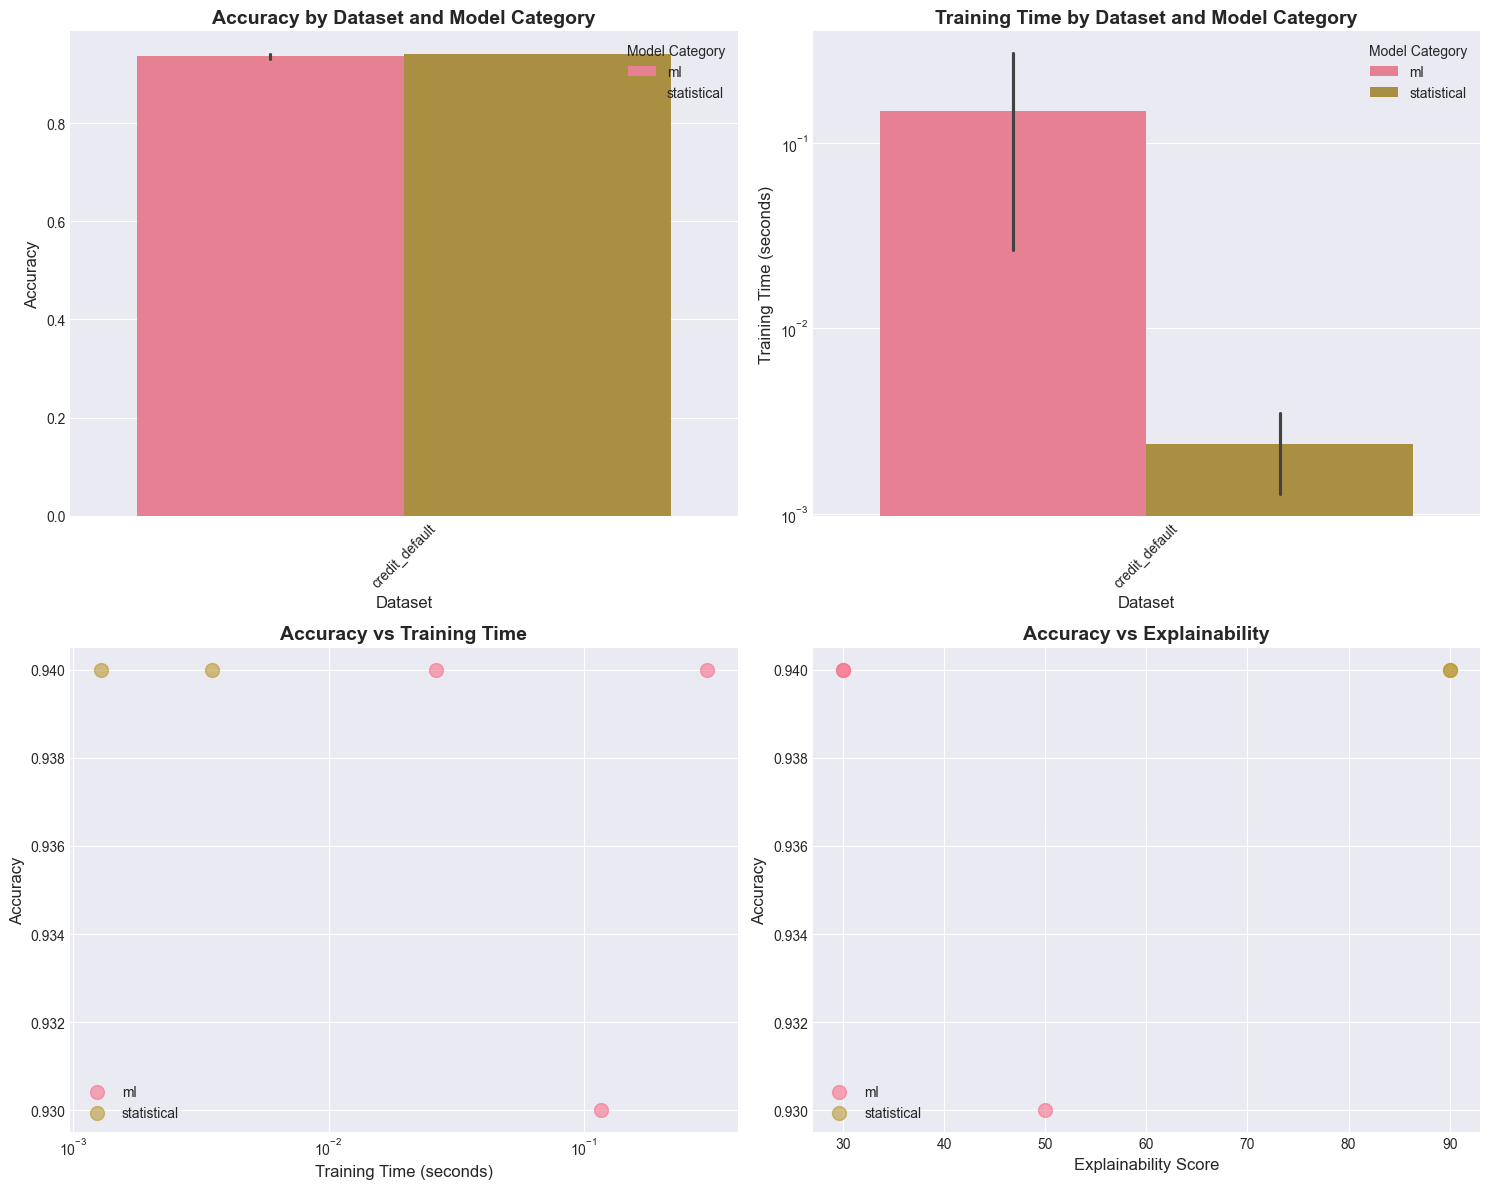

✅ Visualizations created!


In [5]:
# Combine all results for visualization
all_results_combined = []
for dataset_name, data in all_dataset_results.items():
    df = data['results_df'].copy()
    df['dataset'] = dataset_name
    all_results_combined.append(df)

combined_df = pd.concat(all_results_combined, ignore_index=True)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy comparison
ax1 = axes[0, 0]
sns.barplot(data=combined_df, x='dataset', y='test_accuracy', hue='model_category', ax=ax1)
ax1.set_title('Accuracy by Dataset and Model Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(title='Model Category')
ax1.tick_params(axis='x', rotation=45)

# 2. Training time comparison
ax2 = axes[0, 1]
sns.barplot(data=combined_df, x='dataset', y='training_time', hue='model_category', ax=ax2)
ax2.set_title('Training Time by Dataset and Model Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dataset', fontsize=12)
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.legend(title='Model Category')
ax2.tick_params(axis='x', rotation=45)
ax2.set_yscale('log')

# 3. Accuracy vs Training Time
ax3 = axes[1, 0]
for category in combined_df['model_category'].unique():
    data = combined_df[combined_df['model_category'] == category]
    ax3.scatter(data['training_time'], data['test_accuracy'], 
               label=category, alpha=0.6, s=100)
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Accuracy vs Training Time', fontsize=14, fontweight='bold')
ax3.legend()
ax3.set_xscale('log')

# 4. Explainability vs Accuracy
ax4 = axes[1, 1]
for category in combined_df['model_category'].unique():
    data = combined_df[combined_df['model_category'] == category]
    ax4.scatter(data['explainability_score'], data['test_accuracy'], 
               label=category, alpha=0.6, s=100)
ax4.set_xlabel('Explainability Score', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Accuracy vs Explainability', fontsize=14, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")


## Summary Statistics

Display summary statistics across all datasets.


In [6]:
# Summary statistics
print("="*80)
print("CLASSIFICATION MODELS COMPARISON SUMMARY")
print("="*80)

print("\n📊 Overall Performance by Model Category:")
summary = combined_df.groupby('model_category').agg({
    'test_accuracy': ['mean', 'std', 'min', 'max'],
    'training_time': ['mean', 'std'],
    'explainability_score': 'mean'
}).round(4)
print(summary)

print("\n🏆 Best Model per Dataset:")
for dataset in classification_datasets:
    if dataset in all_dataset_results:
        df = all_dataset_results[dataset]['results_df']
        best_model = df.loc[df['test_accuracy'].idxmax()]
        print(f"\n{dataset.upper()}:")
        print(f"  Model: {best_model['model_name']}")
        print(f"  Category: {best_model['model_category']}")
        print(f"  Accuracy: {best_model['test_accuracy']:.4f}")
        print(f"  Training Time: {best_model['training_time']:.4f}s")

print("\n⚡ Fastest Model:")
fastest = combined_df.loc[combined_df['training_time'].idxmin()]
print(f"  Model: {fastest['model_name']}")
print(f"  Dataset: {fastest['dataset']}")
print(f"  Training Time: {fastest['training_time']:.4f}s")

print("\n🧠 Most Interpretable Model:")
most_interp = combined_df.loc[combined_df['explainability_score'].idxmax()]
print(f"  Model: {most_interp['model_name']}")
print(f"  Dataset: {most_interp['dataset']}")
print(f"  Explainability Score: {most_interp['explainability_score']}/100")

print("\n" + "="*80)


CLASSIFICATION MODELS COMPARISON SUMMARY

📊 Overall Performance by Model Category:
               test_accuracy                     training_time          \
                        mean     std   min   max          mean     std   
model_category                                                           
ml                    0.9367  0.0058  0.93  0.94        0.1489  0.1415   
statistical           0.9400  0.0000  0.94  0.94        0.0024  0.0016   

               explainability_score  
                               mean  
model_category                       
ml                          36.6667  
statistical                 90.0000  

🏆 Best Model per Dataset:

CREDIT_DEFAULT:
  Model: Support Vector Machine
  Category: ml
  Accuracy: 0.9400
  Training Time: 0.0263s

⚡ Fastest Model:
  Model: Logistic Regression (statsmodels)
  Dataset: credit_default
  Training Time: 0.0013s

🧠 Most Interpretable Model:
  Model: Logistic Regression (statsmodels)
  Dataset: credit_default
  Explainab